In [ ]:
"""Problem: Simple Linear Regression using Gradient Descent using Stochastic and Mini-batch Gradient Descent

Daataset: Create single feature single target dataset using sklearn.datasets.make_regresion

Task: (a) Apply Stochastic Gradient Descent on the dataset and find the coefficients theta0 and theta1
Task: (b) Apply Mini-batch Gradient Descent on the dataset and find the coefficients theta0 and theta1

Use matplotlib to perform data analysis on the dataset and plot scatter of data, plot distribution of feature and target

Normalize the dataset

Apply the appropriate gradient descent method

Calculate the coefficients

Plot the linear regression line

Analyze the model on various values of eta

Analyze the model on different size of data

Compare both coefficients and MSE obtained using both methods"""

In [ ]:
print(f"Name:SAMIM ALI, STD ID : 202404435")

Name:SAMIM ALI, STD ID : 202404435


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


In [ ]:
# Generate dataset
n_samples = 100  # Change this for different dataset sizes
X, y = make_regression(n_samples=n_samples, n_features=1, noise=30, random_state=42)

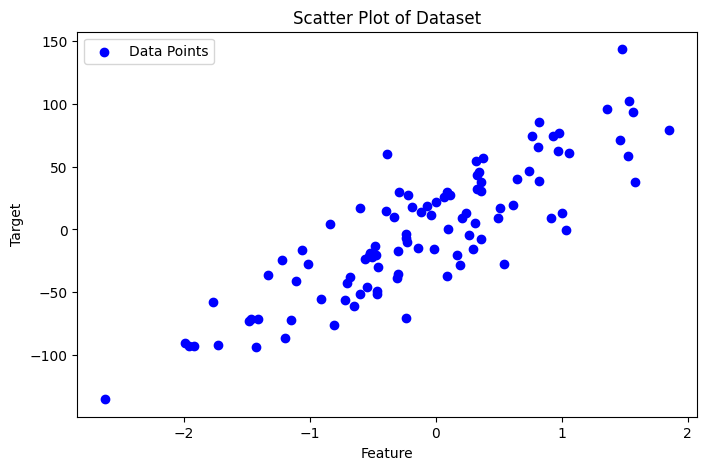

In [ ]:
# Scatter plot of the dataset
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label="Data Points")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Scatter Plot of Dataset")
plt.legend()
plt.show()

In [ ]:
# Normalize the dataset manually (Mean Normalization)
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std

# Add bias term (column of ones)
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

In [ ]:
# Initialize parameters
theta = np.zeros(2)
learning_rate = 0.1  # Modify for different values of eta
iterations = 1000

In [ ]:
# Stochastic Gradient Descent Function
def stochastic_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        for i in range(m):
            prediction = np.dot(X[i], theta)
            error = prediction - y[i]
            gradient = X[i] * error
            theta -= learning_rate * gradient

        cost = (1/(2*m)) * np.sum((np.dot(X, theta) - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history

In [ ]:
# Apply SGD
theta_sgd, cost_history_sgd = stochastic_gradient_descent(X_scaled, y, theta.copy(), learning_rate, iterations)

In [ ]:
# Mini-Batch Gradient Descent Function
def mini_batch_gradient_descent(X, y, theta, learning_rate, iterations, batch_size):
    m = len(y)
    cost_history = []
    n_batches = int(m / batch_size)

    for _ in range(iterations):
        for i in range(n_batches):
            start = i * batch_size
            end = start + batch_size
            X_batch = X[start:end]
            y_batch = y[start:end]

            prediction = np.dot(X_batch, theta)
            error = prediction - y_batch
            gradient = (1/batch_size) * np.dot(X_batch.T, error)
            theta -= learning_rate * gradient

        cost = (1/(2*m)) * np.sum((np.dot(X, theta) - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history

In [ ]:
# Apply Mini-Batch Gradient Descent
batch_size = 20  # Change for different batch sizes
theta_mini_batch, cost_history_mini_batch = mini_batch_gradient_descent(X_scaled, y, theta.copy(), learning_rate, iterations, batch_size)

# Print final coefficients
print(f"SGD Coefficients: theta0 = {theta_sgd[0]}, theta1 = {theta_sgd[1]}")
print(f"Mini-Batch GD Coefficients: theta0 = {theta_mini_batch[0]}, theta1 = {theta_mini_batch[1]}")

SGD Coefficients: theta0 = -6.474221319985444, theta1 = 48.21248247006232
Mini-Batch GD Coefficients: theta0 = -1.1749079160953912, theta1 = 45.116256314229325


In [ ]:
# Compute Mean Squared Error (MSE)
mse_sgd = np.mean((np.dot(X_scaled, theta_sgd) - y) ** 2)
mse_mini_batch = np.mean((np.dot(X_scaled, theta_mini_batch) - y) ** 2)

print(f"MSE (SGD): {mse_sgd}")
print(f"MSE (Mini-Batch GD): {mse_mini_batch}")

MSE (SGD): 735.6300010084918
MSE (Mini-Batch GD): 702.7506626796792


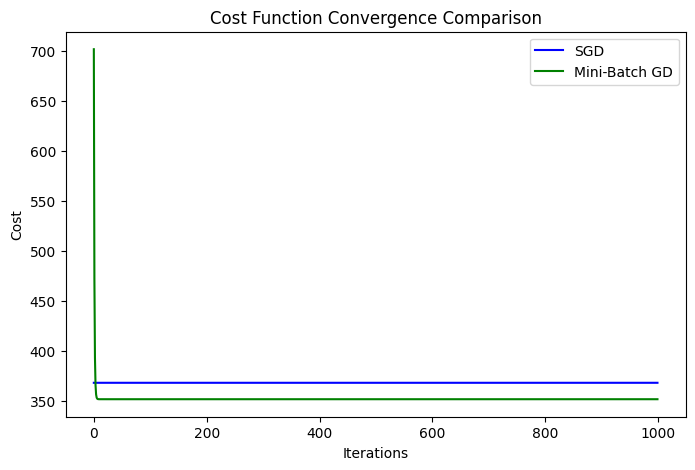

In [ ]:
# Plot Cost Function Convergence
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history_sgd, label="SGD", color='blue')
plt.plot(range(iterations), cost_history_mini_batch, label="Mini-Batch GD", color='green')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function Convergence Comparison")
plt.legend()
plt.show()

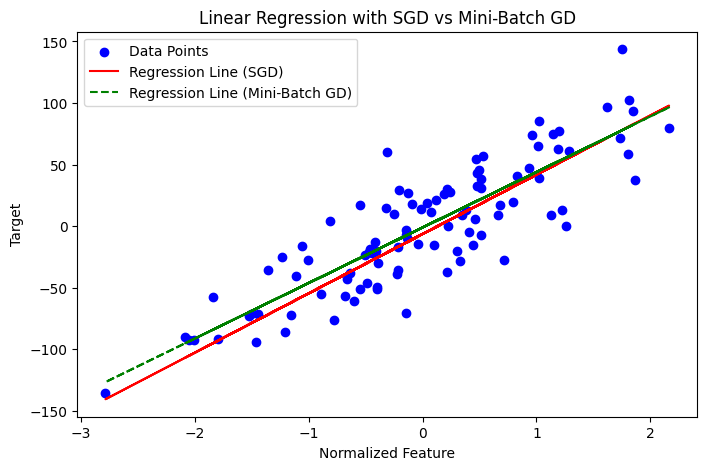

In [ ]:
# Plot Regression Lines
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 1], y, color='blue', label="Data Points")
plt.plot(X_scaled[:, 1], np.dot(X_scaled, theta_sgd), color='red', label="Regression Line (SGD)")
plt.plot(X_scaled[:, 1], np.dot(X_scaled, theta_mini_batch), color='green', linestyle='dashed', label="Regression Line (Mini-Batch GD)")
plt.xlabel("Normalized Feature")
plt.ylabel("Target")
plt.title("Linear Regression with SGD vs Mini-Batch GD")
plt.legend()
plt.show()